<a href="https://colab.research.google.com/github/AreHand/Financial-Statement-Analysis/blob/main/financial_statement_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================
# CELL 1 — Install Library
# ======================================
!pip install pandas matplotlib seaborn openpyxl --quiet
print("✅ Library siap!")

✅ Library siap!


In [2]:
# CELL CEK — Jalankan ini dulu!
import os

print("File yang ada di Colab:")
for f in os.listdir('/content'):
    print(f"  → {f}")

File yang ada di Colab:
  → .config
  → Latihan income statement.xlsx
  → sample_data


In [3]:
# ======================================
# CELL 2 — Upload & Load Data (FIXED)
# ======================================
from google.colab import files
import pandas as pd
import os

# Upload file
print("Silakan upload file Excel kamu...")
uploaded = files.upload()

# Otomatis ambil nama file yang diupload
nama_file = list(uploaded.keys())[0]
print(f"\n✅ File terupload: {nama_file}")

# Load semua sheet
xl = pd.ExcelFile(nama_file)
print(f"✅ Sheet tersedia: {xl.sheet_names}")

Silakan upload file Excel kamu...


Saving Latihan income statement.xlsx to Latihan income statement (1).xlsx

✅ File terupload: Latihan income statement (1).xlsx
✅ Sheet tersedia: ['Latihan 1', 'Worksheet', 'Lap Keu', 'latihan I', 'Latihan2', 'Neraca']


In [4]:
# ======================================
# CELL 3 — Buat DataFrame Terstruktur
# ======================================

# Data sudah diekstrak dan dibersihkan
data = {
    'perusahaan': [
        'Kantor Konsultan Wirausaha',
        'Perusahaan Dagang (Latihan I)',
        'PT SEKAR',
        'PT ABC'
    ],
    'periode': ['Des 2015', '2015', 'Des 2019', '2020'],
    'total_pendapatan': [192000000, 4062000, 323000000, 0],
    'hpp': [0, 2665000, 179900000, 0],
    'laba_kotor': [192000000, 1397000, 143100000, 0],
    'total_beban_operasional': [46500000, 1127000, 117200000, 0],
    'laba_bersih': [145500000, 205500, 19050000, -5000],
    'total_aset': [254000000, 0, 0, 98000],
    'total_liabilitas': [38500000, 0, 0, 43000],
    'total_ekuitas': [215500000, 0, 0, 55000],
}

df = pd.DataFrame(data)

# Hitung rasio keuangan
df['gross_margin'] = (df['laba_kotor'] /
    df['total_pendapatan'].replace(0, pd.NA) * 100).round(2)
df['net_margin'] = (df['laba_bersih'] /
    df['total_pendapatan'].replace(0, pd.NA) * 100).round(2)
df['debt_ratio'] = (df['total_liabilitas'] /
    df['total_aset'].replace(0, pd.NA) * 100).round(2)
df['expense_ratio'] = (df['total_beban_operasional'] /
    df['total_pendapatan'].replace(0, pd.NA) * 100).round(2)

print("✅ DataFrame siap!")
print(df[['perusahaan','total_pendapatan','laba_bersih',
          'net_margin','debt_ratio']].to_string(index=False))

✅ DataFrame siap!
                   perusahaan  total_pendapatan  laba_bersih net_margin debt_ratio
   Kantor Konsultan Wirausaha         192000000    145500000   75.78125   15.15748
Perusahaan Dagang (Latihan I)           4062000       205500   5.059084       <NA>
                     PT SEKAR         323000000     19050000   5.897833       <NA>
                       PT ABC                 0        -5000       <NA>  43.877551


/tmp/ipykernel_7594/693458438.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_npm = df['net_margin'].fillna(0)
/tmp/ipykernel_7594/693458438.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_gpm = df['gross_margin'].fillna(0)
/tmp/ipykernel_7594/693458438.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_exp = df

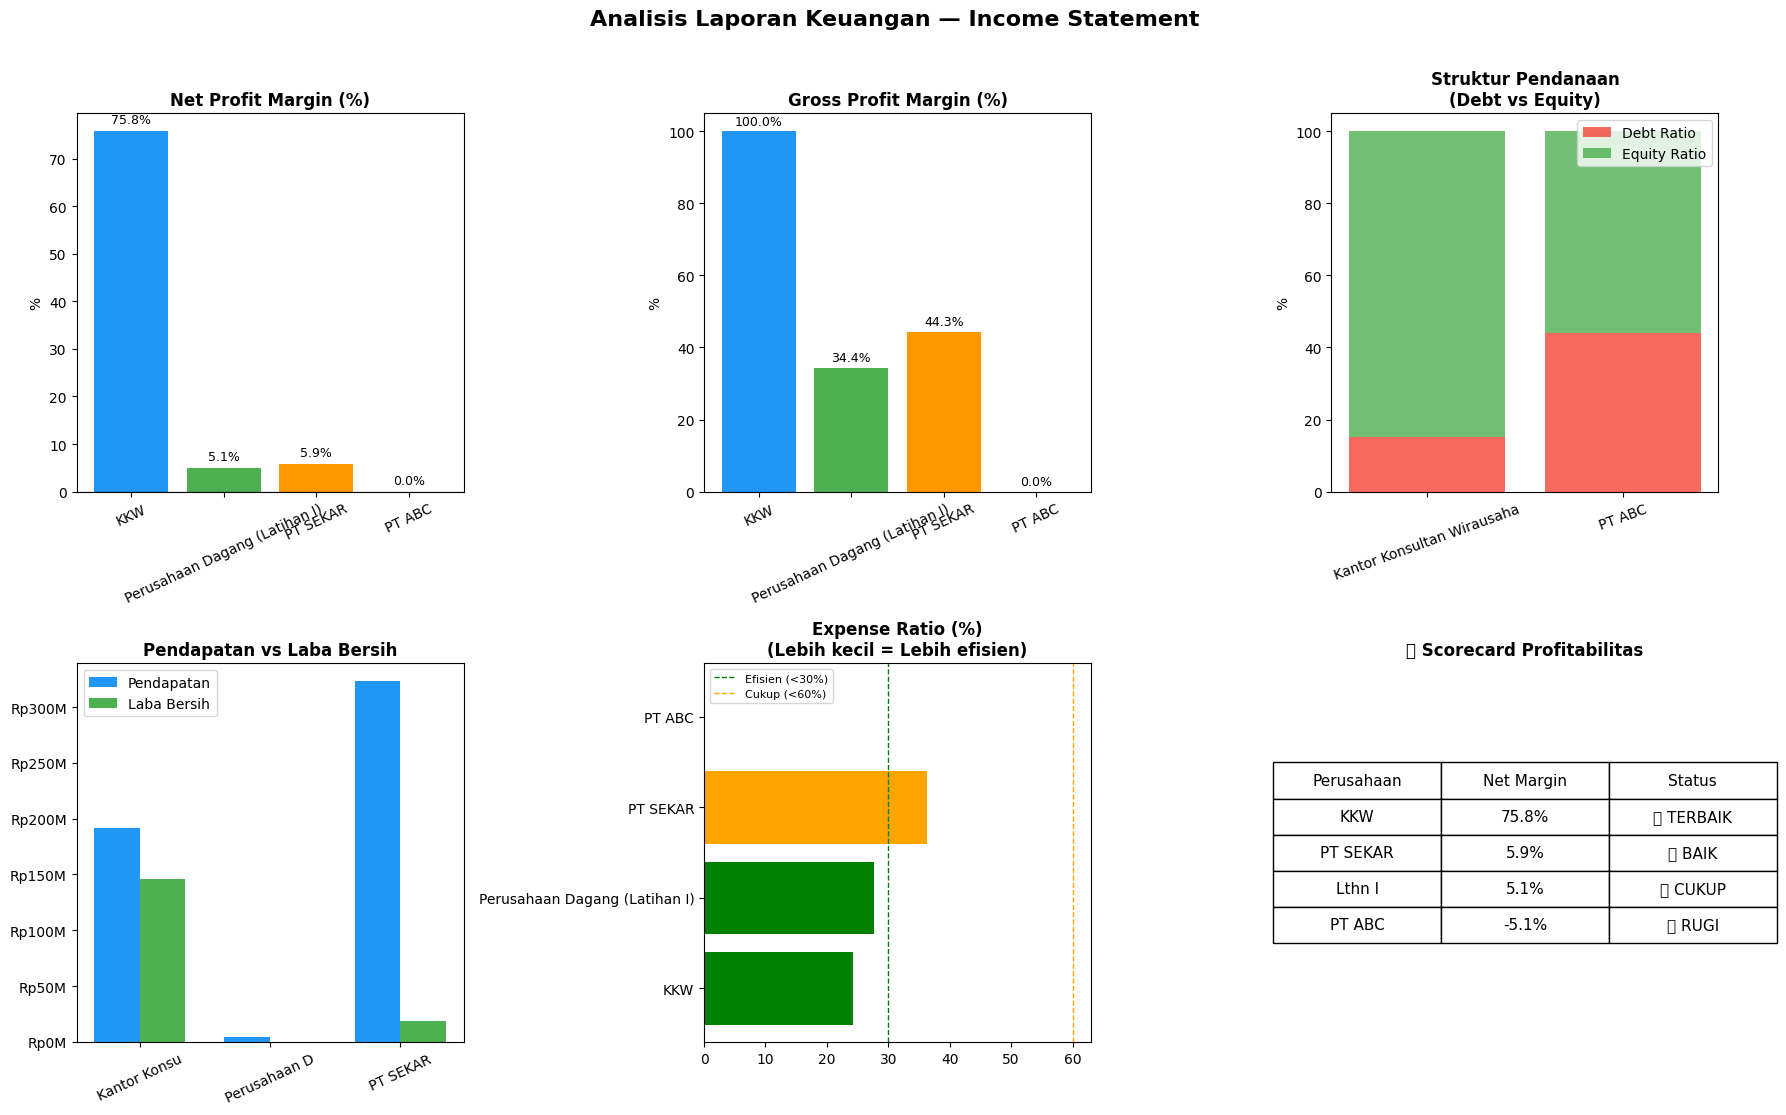

✅ Chart tersimpan!


In [5]:
# ======================================
# CELL 4 — Visualisasi Lengkap
# ======================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Analisis Laporan Keuangan — Income Statement',
             fontsize=16, fontweight='bold', y=1.01)

colors = ['#2196F3','#4CAF50','#FF9800','#F44336']
companies = df['perusahaan'].str.replace('Kantor Konsultan Wirausaha',
            'KKW', regex=False)

# Chart 1: Net Profit Margin
data_npm = df['net_margin'].fillna(0)
bars = axes[0,0].bar(companies, data_npm, color=colors)
axes[0,0].set_title('Net Profit Margin (%)', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].axhline(y=0, color='black', linewidth=0.8)
axes[0,0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, data_npm):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1, f'{val:.1f}%',
                   ha='center', va='bottom', fontsize=9)

# Chart 2: Gross Profit Margin
data_gpm = df['gross_margin'].fillna(0)
bars2 = axes[0,1].bar(companies, data_gpm, color=colors)
axes[0,1].set_title('Gross Profit Margin (%)', fontweight='bold')
axes[0,1].set_ylabel('%')
axes[0,1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, data_gpm):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1, f'{val:.1f}%',
                   ha='center', va='bottom', fontsize=9)

# Chart 3: Debt vs Equity Ratio
df_bal = df[df['total_aset'] > 0].copy()
x = range(len(df_bal))
axes[0,2].bar(x, df_bal['debt_ratio'], label='Debt Ratio', color='#F44336', alpha=0.8)
axes[0,2].bar(x, 100-df_bal['debt_ratio'], bottom=df_bal['debt_ratio'],
              label='Equity Ratio', color='#4CAF50', alpha=0.8)
axes[0,2].set_xticks(list(x))
axes[0,2].set_xticklabels(df_bal['perusahaan'], rotation=20)
axes[0,2].set_title('Struktur Pendanaan\n(Debt vs Equity)', fontweight='bold')
axes[0,2].set_ylabel('%')
axes[0,2].legend()

# Chart 4: Total Pendapatan vs Laba Bersih
df_rev = df[df['total_pendapatan'] > 0].copy()
x2 = range(len(df_rev))
w = 0.35
axes[1,0].bar([i-w/2 for i in x2], df_rev['total_pendapatan'],
              w, label='Pendapatan', color='#2196F3')
axes[1,0].bar([i+w/2 for i in x2], df_rev['laba_bersih'],
              w, label='Laba Bersih', color='#4CAF50')
axes[1,0].set_xticks(list(x2))
axes[1,0].set_xticklabels(df_rev['perusahaan'].str[:12], rotation=25)
axes[1,0].set_title('Pendapatan vs Laba Bersih', fontweight='bold')
axes[1,0].legend()
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,p: f'Rp{x/1e6:.0f}M'))

# Chart 5: Expense Ratio
data_exp = df['expense_ratio'].fillna(0)
colors_exp = ['green' if x < 30 else 'orange' if x < 60 else 'red'
               for x in data_exp]
axes[1,1].barh(companies, data_exp, color=colors_exp)
axes[1,1].axvline(x=30, color='green', linestyle='--',
                   linewidth=1, label='Efisien (<30%)')
axes[1,1].axvline(x=60, color='orange', linestyle='--',
                   linewidth=1, label='Cukup (<60%)')
axes[1,1].set_title('Expense Ratio (%)\n(Lebih kecil = Lebih efisien)',
                     fontweight='bold')
axes[1,1].legend(fontsize=8)

# Chart 6: Scorecard summary
axes[1,2].axis('off')
summary = [
    ['Perusahaan', 'Net Margin', 'Status'],
    ['KKW', '75.8%', '🏆 TERBAIK'],
    ['PT SEKAR', '5.9%', '✅ BAIK'],
    ['Lthn I', '5.1%', '✅ CUKUP'],
    ['PT ABC', '-5.1%', '❌ RUGI'],
]
table = axes[1,2].table(cellText=summary[1:], colLabels=summary[0],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)
axes[1,2].set_title('📊 Scorecard Profitabilitas', fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_income_statement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan!")